In [3]:
import numpy as np
import pandas as pd

import matplotlib
import matplotlib.pyplot as plt
from docutils.languages.ru import labels

matplotlib.style.use('ggplot')
%matplotlib inline
%config InlineBackend.figure_format = 'svg'

import os

In [4]:
from src.config import FILE_BEVERAGE, ENCODINGS

In [5]:
os.chdir(r"C:\Users\print\OneDrive\Рабочий стол\Data_Analysis_in_Python\claster_analisis\data")

In [6]:
os.getcwd()

'C:\\Users\\print\\OneDrive\\Рабочий стол\\Data_Analysis_in_Python\\claster_analisis\\data'

In [53]:
df = pd.read_csv(FILE_BEVERAGE, encoding=ENCODINGS[0], sep=';', index_col='numb.obs')
df2 = pd.read_csv(FILE_BEVERAGE, encoding=ENCODINGS[0], sep=';', index_col='numb.obs')

In [8]:
df.head(5)

,COKE,D_COKE,D_PEPSI,D_7UP,PEPSI,SPRITE,TAB,SEVENUP
numb.obs,,,,,,,,
1,1,0,0,0,1,1,0,1
2,1,0,0,0,1,0,0,0
3,1,0,0,0,1,0,0,0
4,0,1,0,1,0,0,1,0
5,1,0,0,0,1,0,0,0


In [9]:
df.tail(5)

,COKE,D_COKE,D_PEPSI,D_7UP,PEPSI,SPRITE,TAB,SEVENUP
numb.obs,,,,,,,,
30,0,1,1,0,0,0,1,0
31,1,0,0,0,1,0,0,1
32,0,1,1,0,0,0,1,0
33,1,0,0,0,1,0,0,1
34,0,1,1,1,0,0,1,0


In [10]:
print(df)

          COKE  D_COKE  D_PEPSI  D_7UP  PEPSI  SPRITE  TAB  SEVENUP
numb.obs                                                           
1            1       0        0      0      1       1    0        1
2            1       0        0      0      1       0    0        0
3            1       0        0      0      1       0    0        0
4            0       1        0      1      0       0    1        0
5            1       0        0      0      1       0    0        0
6            1       0        0      0      1       1    0        0
7            0       1        1      1      0       0    1        0
8            1       1        0      0      1       1    0        1
9            1       1        0      0      0       1    1        1
10           1       0        0      0      1       0    0        1
11           1       0        0      0      1       1    0        0
12           0       1        0      0      0       0    1        0
13           0       0        1      1      0   

In [11]:
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster

In [12]:
Z = linkage(df, method='ward', metric='euclidean')

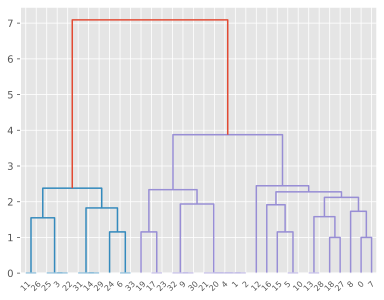

In [13]:
dendrogram(Z);

In [14]:
print(Z)

[[ 5.         10.          0.          2.        ]
 [ 1.          2.          0.          2.        ]
 [ 4.         35.          0.          3.        ]
 [ 3.         22.          0.          2.        ]
 [20.         36.          0.          4.        ]
 [ 6.         33.          0.          2.        ]
 [ 9.         30.          0.          2.        ]
 [13.         28.          0.          2.        ]
 [32.         40.          0.          3.        ]
 [17.         23.          0.          2.        ]
 [11.         26.          0.          2.        ]
 [14.         29.          0.          2.        ]
 [25.         37.          0.          3.        ]
 [31.         45.          0.          3.        ]
 [21.         38.          0.          5.        ]
 [ 0.          7.          1.          2.        ]
 [18.         27.          1.          2.        ]
 [15.         34.          1.15470054  3.        ]
 [24.         39.          1.15470054  3.        ]
 [19.         43.          1.15

In [15]:
print(type(Z))
print(Z.shape)

<class 'numpy.ndarray'>
(33, 4)


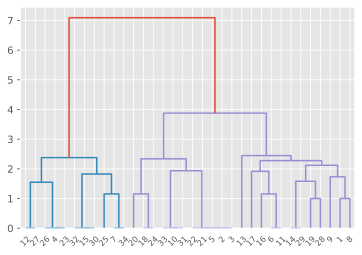

In [16]:
fig = plt.figure(figsize = (6,4))
dn = dendrogram(Z, labels=df.index.tolist())

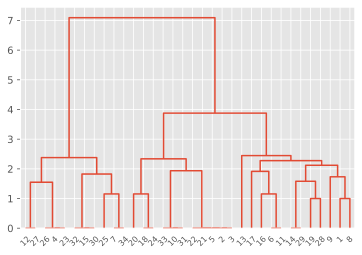

In [17]:
fig = plt.figure(figsize=(6,4))
dn = dendrogram(Z, color_threshold=-1, labels=df.index.tolist())

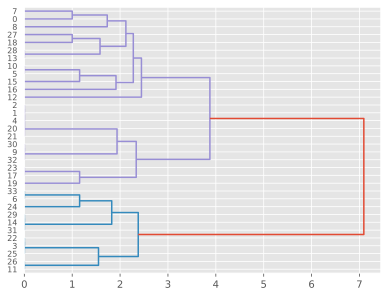

In [27]:
dn = dendrogram(Z, orientation = "right")

In [76]:
df['cluster'] = fcluster(Z, t=3.1, criterion='distance')
#df['cluster'] = fcluster(Z, 3, criterion='maxclust')

In [77]:
df

,COKE,D_COKE,D_PEPSI,D_7UP,PEPSI,SPRITE,TAB,SEVENUP,cluster
numb.obs,,,,,,,,,
1,1,0,0,0,1,1,0,1,3
2,1,0,0,0,1,0,0,0,2
3,1,0,0,0,1,0,0,0,2
4,0,1,0,1,0,0,1,0,1
5,1,0,0,0,1,0,0,0,2
6,1,0,0,0,1,1,0,0,3
7,0,1,1,1,0,0,1,0,1
8,1,1,0,0,1,1,0,1,3
9,1,1,0,0,0,1,1,1,3


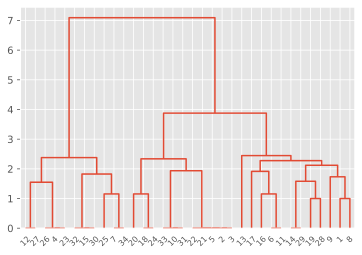

In [21]:
fig = plt.figure(figsize=(6,4))
dn = dendrogram(Z, color_threshold=-1, labels=df.index.tolist())

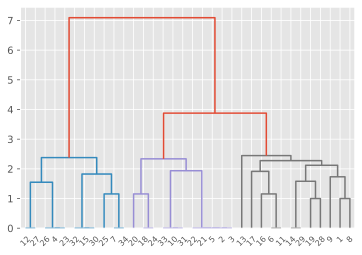

In [25]:
fig = plt.figure(figsize=(6,4))
dn = dendrogram(Z, color_threshold=3.2, labels=df.index.tolist())

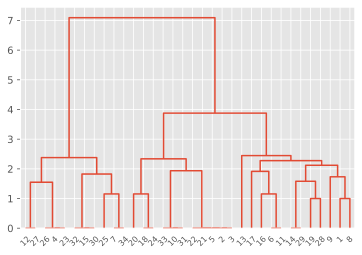

In [38]:
fig = plt.figure(figsize=(6,4))
dn = dendrogram(Z, color_threshold=-1, labels=df.index.tolist())

In [50]:
dfc = df.copy()
dfc['cluster'].value_counts().sort_index()

cluster
1    11
2    11
3    12
Name: count, dtype: int64

In [51]:
profile = dfc.groupby('cluster').mean().round(2)
profile

,COKE,D_COKE,D_PEPSI,D_7UP,PEPSI,SPRITE,TAB,SEVENUP
cluster,,,,,,,,
1,0.00,1.00,0.55,0.55,0.00,0.00,0.91,0.00
2,1.00,0.27,0.09,0.00,1.00,0.00,0.00,0.27
3,0.75,0.25,0.08,0.08,0.42,0.92,0.08,0.50


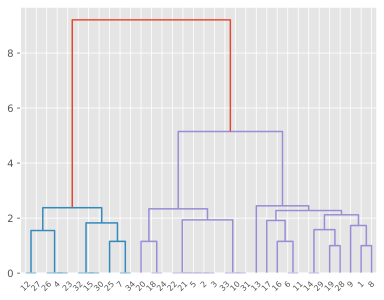

In [57]:
dn2 = dendrogram(Z, color_threshold=6, labels=df.index.tolist())

In [69]:
df2['cluster'] = fcluster(Z, t=6, criterion='distance')

In [70]:
df2

,COKE,D_COKE,D_PEPSI,D_7UP,PEPSI,SPRITE,TAB,SEVENUP,cluster
numb.obs,,,,,,,,,
1,1,0,0,0,1,1,0,1,2
2,1,0,0,0,1,0,0,0,2
3,1,0,0,0,1,0,0,0,2
4,0,1,0,1,0,0,1,0,1
5,1,0,0,0,1,0,0,0,2
6,1,0,0,0,1,1,0,0,2
7,0,1,1,1,0,0,1,0,1
8,1,1,0,0,1,1,0,1,2
9,1,1,0,0,0,1,1,1,2


In [62]:
profile2 = df2.groupby('cluster').mean().round(2)
profile2

,COKE,D_COKE,D_PEPSI,D_7UP,PEPSI,SPRITE,TAB,SEVENUP
cluster,,,,,,,,
1,0.00,1.00,0.55,0.55,0.0,0.00,0.91,0.00
2,0.87,0.26,0.09,0.04,0.7,0.48,0.04,0.39


In [71]:
df2['cluster'].value_counts().sort_index()

cluster
1    11
2    23
Name: count, dtype: int64

In [74]:
df2.groupby('cluster').size() # 2й вариант подсчета столбца(лучше использовать его)

cluster
1    11
2    23
dtype: int64

In [81]:
df['cluster'].value_counts().sort_index()

cluster
1    11
2    11
3    12
Name: count, dtype: int64

In [79]:
df.groupby('cluster').size() # 2й вариант подсчета столбца(лучше использовать его)

cluster
1    11
2    11
3    12
dtype: int64

In [84]:
df[df['cluster']==1].index.values

array([ 4,  7, 12, 15, 23, 25, 26, 27, 30, 32, 34], dtype=int64)

In [85]:
df.groupby(fcluster(Z, t=2, criterion='maxclust')).mean()

,COKE,D_COKE,D_PEPSI,D_7UP,PEPSI,SPRITE,TAB,SEVENUP,cluster
1,0.000000,1.00000,0.545455,0.545455,0.000000,0.000000,0.909091,0.000000,1.000000
2,0.869565,0.26087,0.086957,0.043478,0.695652,0.478261,0.043478,0.391304,2.521739


In [86]:
df.groupby(fcluster(Z, t=4, criterion='maxclust')).mean()

,COKE,D_COKE,D_PEPSI,D_7UP,PEPSI,SPRITE,TAB,SEVENUP,cluster
1,0.000000,1.000000,0.545455,0.545455,0.000000,0.000000,0.909091,0.000000,1.0
2,1.000000,0.272727,0.090909,0.000000,1.000000,0.000000,0.000000,0.272727,2.0
3,0.818182,0.272727,0.000000,0.000000,0.454545,0.909091,0.090909,0.454545,3.0
4,0.000000,0.000000,1.000000,1.000000,0.000000,1.000000,0.000000,1.000000,3.0


In [87]:
print(Z[:15])

[[ 5. 10.  0.  2.]
 [ 1.  2.  0.  2.]
 [ 4. 35.  0.  3.]
 [ 3. 22.  0.  2.]
 [20. 36.  0.  4.]
 [ 6. 33.  0.  2.]
 [13. 28.  0.  2.]
 [ 9. 30.  0.  2.]
 [21. 38.  0.  5.]
 [32. 41.  0.  3.]
 [11. 26.  0.  2.]
 [17. 23.  0.  2.]
 [14. 29.  0.  2.]
 [25. 37.  0.  3.]
 [31. 46.  0.  3.]]
